In [1]:
import pandas as pd

incidents = pd.read_csv('../data/raw/incidents_master.csv')
financial = pd.read_csv('../data/raw/financial_impact.csv')
market = pd.read_csv('../data/raw/market_impact.csv')

print("Incidents:", incidents.shape)
print("Financial:", financial.shape)
print("Market:", market.shape)

incidents.head()

Incidents: (850, 32)
Financial: (778, 19)
Market: (358, 31)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [2]:
print(financial.columns.tolist())
financial.head()

['incident_id', 'direct_loss_usd', 'direct_loss_method', 'ransom_demanded_usd', 'ransom_paid_usd', 'ransom_source', 'recovery_cost_usd', 'legal_fees_usd', 'regulatory_fine_usd', 'insurance_payout_usd', 'total_loss_usd', 'total_loss_method', 'total_loss_lower_bound', 'total_loss_upper_bound', 'inflation_adjusted_usd', 'cpi_index_used', 'notes', 'created_at', 'updated_at']


,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,9354133.80,disclosed,7648967.81,1.452521e+07,11098475.91,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,5466301.48,estimated,3519806.28,6.755823e+06,6485647.58,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [3]:
print(market.columns.tolist())
market.head()

['incident_id', 'stock_ticker', 'price_7d_before', 'price_disclosure_day', 'price_1d_after', 'price_7d_after', 'price_30d_after', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'abnormal_return_1d', 'abnormal_return_7d', 'abnormal_return_30d', 'car_neg1_to_pos1', 'car_0_to_7', 'car_0_to_30', 'car_0_to_90', 't_statistic_1d', 'p_value_1d', 't_statistic_30d', 'p_value_30d', 'earnings_announcement_within_7d', 'market_cap_at_disclosure', 'volume_ratio_disclosure', 'pre_incident_volatility_30d', 'post_incident_volatility_30d', 'days_to_price_recovery', 'notes', 'created_at', 'updated_at']


,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0213-001,STUT.DE,5.34,5.43,5.27,5.36,5.37,2521343,6491913,S&P 500 Consumer Discretionary,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2025-0529-001,BAZA,465.19,441.08,410.45,428.36,429.49,1235984,3250371,S&P 500 Consumer Discretionary,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [5]:
# Merge incidents + financial (every incident should try to have financial data)
df = incidents.merge(financial, on='incident_id', how='left')

# Merge in market data (only public companies will have this - lots of NaN expected, that's fine)
df = df.merge(market, on='incident_id', how='left')

print(df.shape)
df.head()

(850, 80)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker_x,incident_date,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [6]:
df.isnull().sum().sort_values(ascending=False).head(15)

review_flag                780
ransom_paid_usd            764
ransom_source              764
notes                      758
regulatory_fine_usd        718
industry_secondary         697
ransom_demanded_usd        644
attack_vector_secondary    639
notes_x                    636
notes_y                    602
days_to_price_recovery     528
car_0_to_7                 492
p_value_1d                 492
t_statistic_1d             492
car_0_to_90                492
dtype: int64

In [7]:
# check which columns got duplicated
print(df.columns[df.columns.str.endswith('_x')].tolist())
print(df.columns[df.columns.str.endswith('_y')].tolist())

['stock_ticker_x', 'notes_x', 'created_at_x', 'updated_at_x']
['notes_y', 'created_at_y', 'updated_at_y', 'stock_ticker_y']


In [8]:
# Drop metadata timestamp columns entirely - not useful for analysis
df = df.drop(columns=['created_at_x', 'updated_at_x', 'created_at_y', 'updated_at_y'])

# Keep one version of stock_ticker, drop the duplicate
df = df.drop(columns=['stock_ticker_y'])
df = df.rename(columns={'stock_ticker_x': 'stock_ticker'})

# Keep one version of notes, drop the duplicate
df = df.drop(columns=['notes_y'])
df = df.rename(columns={'notes_x': 'notes'})

print(df.shape)
df.columns.tolist()

(850, 74)


['incident_id',
 'company_name',
 'company_revenue_usd',
 'country_hq',
 'industry_primary',
 'industry_secondary',
 'employee_count',
 'is_public_company',
 'stock_ticker',
 'incident_date',
 'incident_date_estimated',
 'discovery_date',
 'disclosure_date',
 'attack_vector_primary',
 'attack_vector_secondary',
 'attack_chain',
 'attributed_group',
 'attribution_confidence',
 'data_compromised_records',
 'data_type',
 'systems_affected',
 'downtime_hours',
 'data_source_primary',
 'data_source_secondary',
 'data_source_type',
 'confidence_tier',
 'quality_score',
 'quality_grade',
 'review_flag',
 'notes',
 'direct_loss_usd',
 'direct_loss_method',
 'ransom_demanded_usd',
 'ransom_paid_usd',
 'ransom_source',
 'recovery_cost_usd',
 'legal_fees_usd',
 'regulatory_fine_usd',
 'insurance_payout_usd',
 'total_loss_usd',
 'total_loss_method',
 'total_loss_lower_bound',
 'total_loss_upper_bound',
 'inflation_adjusted_usd',
 'cpi_index_used',
 'price_7d_before',
 'price_disclosure_day',
 'pri

In [9]:
# See how many columns are literally named 'notes', 'created_at', 'updated_at'
print(df.columns.tolist().count('notes'))
print(df.columns.tolist().count('created_at'))
print(df.columns.tolist().count('updated_at'))

2
1
1


In [10]:
# Get positions of duplicate-named columns
cols = df.columns.tolist()
notes_positions = [i for i, c in enumerate(cols) if c == 'notes']
created_positions = [i for i, c in enumerate(cols) if c == 'created_at']
updated_positions = [i for i, c in enumerate(cols) if c == 'updated_at']

print(notes_positions, created_positions, updated_positions)

[29, 71] [72] [73]


In [11]:
# Drop the second 'notes' column (position 71), plus created_at and updated_at entirely
df = df.drop(df.columns[[71, 72, 73]], axis=1)

print(df.shape)
print(df.columns.tolist().count('notes'))  # should now be 1

(850, 70)
0


In [12]:
naics_map = {
    '51': 'Information/Tech',
    '52': 'Finance & Insurance',
    '54': 'Professional/Scientific Services',
    '44-45': 'Retail Trade',
    '62': 'Healthcare',
    '61': 'Education',
    '31-33': 'Manufacturing',
    '22': 'Utilities',
    '48-49': 'Transportation/Warehousing',
    '92': 'Public Administration/Government',
}

df['industry_name'] = df['industry_primary'].astype(str).map(naics_map)

# check how many mapped successfully vs fell through as unknown
print(df['industry_name'].value_counts())
print("Unmapped count:", df['industry_name'].isnull().sum())

industry_name
Healthcare                          142
Finance & Insurance                 128
Information/Tech                    127
Retail Trade                         81
Manufacturing                        79
Public Administration/Government     52
Utilities                            38
Education                            37
Professional/Scientific Services     36
Transportation/Warehousing           23
Name: count, dtype: int64
Unmapped count: 107


In [13]:
unmapped_codes = df.loc[df['industry_name'].isnull(), 'industry_primary'].value_counts()
print(unmapped_codes)

industry_primary
21    21
56    16
72    16
71    14
23    13
42    10
53     8
11     4
81     3
55     2
Name: count, dtype: int64


In [14]:
naics_map = {
    '11': 'Agriculture/Forestry/Fishing',
    '21': 'Mining/Oil & Gas',
    '22': 'Utilities',
    '23': 'Construction',
    '31-33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44-45': 'Retail Trade',
    '48-49': 'Transportation/Warehousing',
    '51': 'Information/Tech',
    '52': 'Finance & Insurance',
    '53': 'Real Estate',
    '54': 'Professional/Scientific Services',
    '55': 'Management of Companies',
    '56': 'Administrative/Support Services',
    '61': 'Education',
    '62': 'Healthcare',
    '71': 'Arts/Entertainment/Recreation',
    '72': 'Accommodation/Food Services',
    '81': 'Other Services',
    '92': 'Public Administration/Government',
}

df['industry_name'] = df['industry_primary'].astype(str).map(naics_map)

print(df['industry_name'].value_counts())
print("Unmapped count:", df['industry_name'].isnull().sum())

industry_name
Healthcare                          142
Finance & Insurance                 128
Information/Tech                    127
Retail Trade                         81
Manufacturing                        79
Public Administration/Government     52
Utilities                            38
Education                            37
Professional/Scientific Services     36
Transportation/Warehousing           23
Mining/Oil & Gas                     21
Administrative/Support Services      16
Accommodation/Food Services          16
Arts/Entertainment/Recreation        14
Construction                         13
Wholesale Trade                      10
Real Estate                           8
Agriculture/Forestry/Fishing          4
Other Services                        3
Management of Companies               2
Name: count, dtype: int64
Unmapped count: 0


In [15]:
# save cleaned/merged dataset for reuse
df.to_csv('../data/processed/merged_breach_data.csv', index=False)

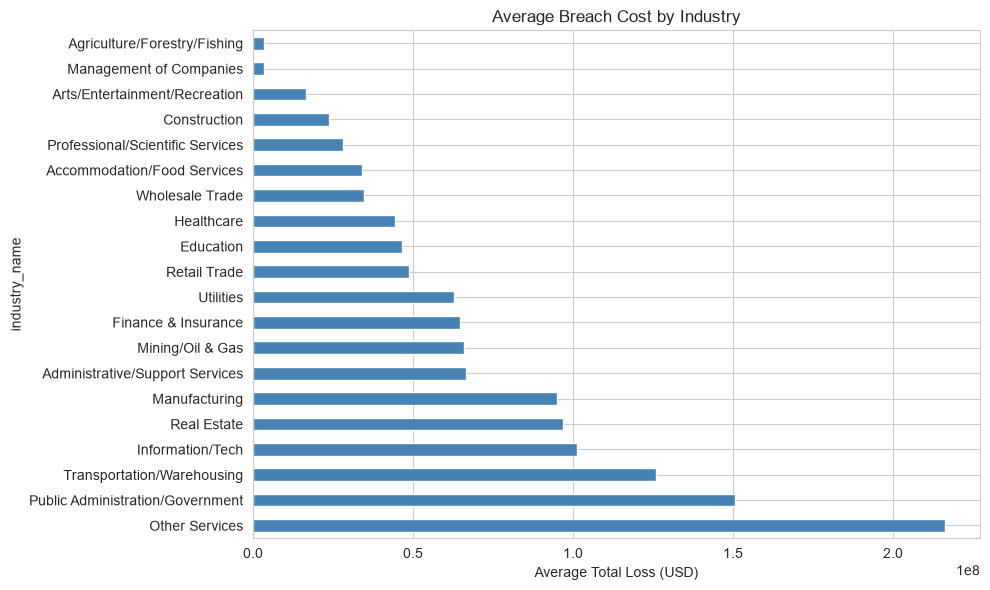

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))
industry_avg_loss = df.groupby('industry_name')['total_loss_usd'].mean().sort_values(ascending=False)
industry_avg_loss.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average Total Loss (USD)')
ax.set_title('Average Breach Cost by Industry')
plt.tight_layout()
plt.savefig('../visuals/avg_loss_by_industry.png', dpi=150)
plt.show()

In [17]:
industry_stats = df.groupby('industry_name')['total_loss_usd'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(industry_stats)

                                          mean  count
industry_name                                        
Other Services                    2.163592e+08      3
Public Administration/Government  1.505071e+08     51
Transportation/Warehousing        1.260418e+08     19
Information/Tech                  1.013027e+08    119
Real Estate                       9.675343e+07      8
Manufacturing                     9.487008e+07     71
Administrative/Support Services   6.642167e+07     16
Mining/Oil & Gas                  6.600995e+07     20
Finance & Insurance               6.453476e+07    115
Utilities                         6.293829e+07     34
Retail Trade                      4.858969e+07     73
Education                         4.658210e+07     33
Healthcare                        4.422081e+07    127
Wholesale Trade                   3.460405e+07      9
Accommodation/Food Services       3.418588e+07     15
Professional/Scientific Services  2.826289e+07     34
Construction                

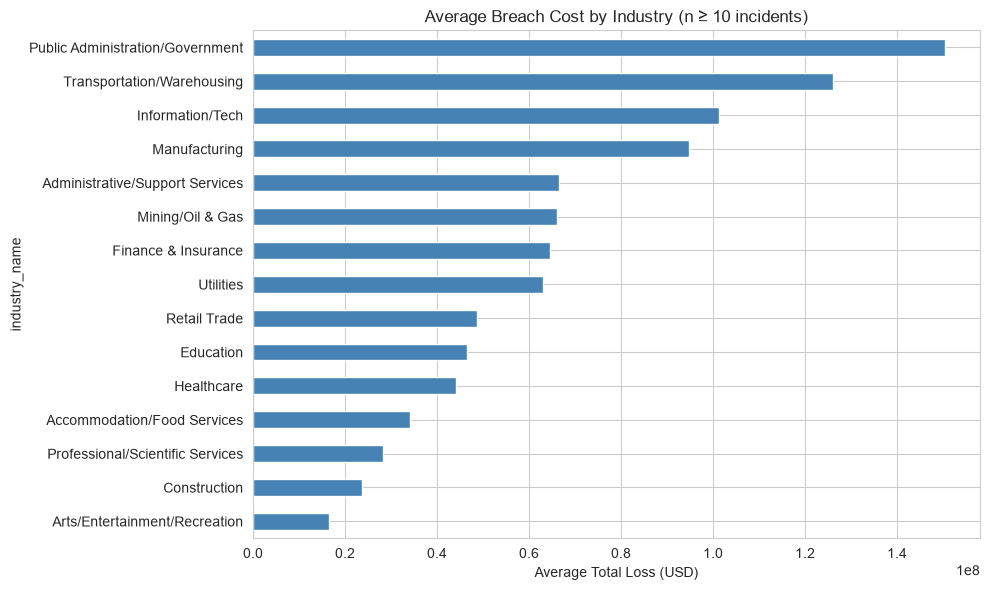

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
reliable_industries = industry_stats[industry_stats['count'] >= 10].sort_values('mean', ascending=False)
reliable_industries['mean'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average Total Loss (USD)')
ax.set_title('Average Breach Cost by Industry (n ≥ 10 incidents)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visuals/avg_loss_by_industry.png', dpi=150)
plt.show()

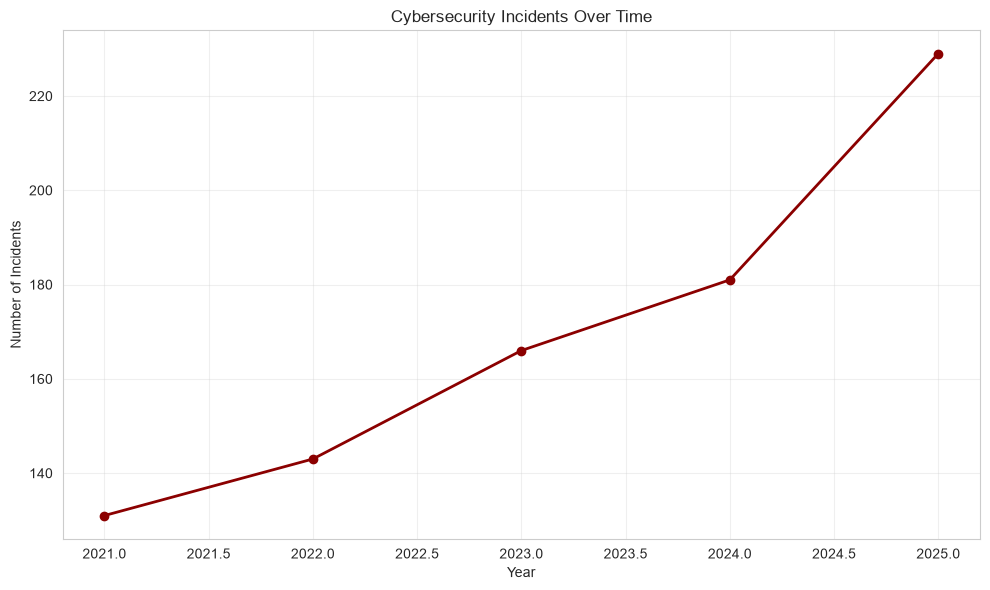

In [19]:
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['incident_year'] = df['incident_date'].dt.year

yearly_counts = df.groupby('incident_year').size()

fig, ax = plt.subplots(figsize=(10, 6))
yearly_counts.plot(kind='line', marker='o', ax=ax, color='darkred', linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.set_title('Cybersecurity Incidents Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/incidents_over_time.png', dpi=150)
plt.show()

In [20]:
vector_by_year = df.groupby(['incident_year', 'attack_vector_primary']).size().unstack(fill_value=0)
print(vector_by_year)

attack_vector_primary  apt  backdoor  data_breach  ddos  malware  phishing  \
incident_year                                                                
2021                    11         2           15     8       14        21   
2022                    15         4           23    11       11        24   
2023                    18         9           23     6       18        24   
2024                    13         8           25    25       16        27   
2025                    27         7           37    17       20        51   

attack_vector_primary  ransomware  supply_chain  trojan  
incident_year                                            
2021                           43            12       5  
2022                           41             8       6  
2023                           50            13       5  
2024                           47            10      10  
2025                           47            15       8  


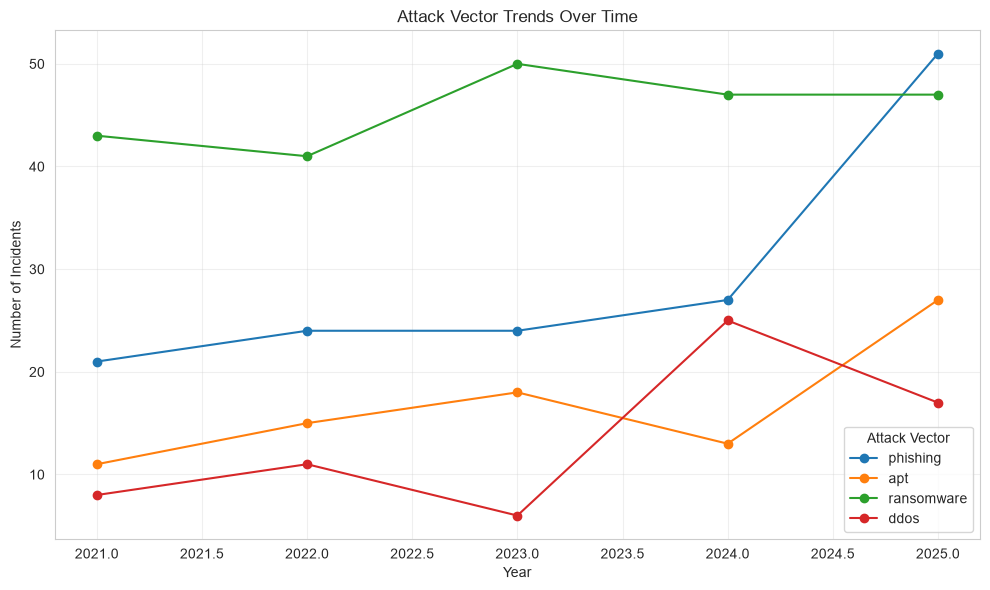

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
vector_by_year[['phishing', 'apt', 'ransomware', 'ddos']].plot(kind='line', marker='o', ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.set_title('Attack Vector Trends Over Time')
ax.legend(title='Attack Vector')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/attack_vector_trends.png', dpi=150)
plt.show()

In [24]:
market_df = df.dropna(subset=['abnormal_return_1d'])
print(f"Companies with market data: {len(market_df)}")

significant_negative = market_df[(market_df['p_value_1d'] < 0.05) & (market_df['abnormal_return_1d'] < 0)]
print(f"Statistically significant negative reaction: {len(significant_negative)} ({len(significant_negative)/len(market_df)*100:.1f}%)")

print(market_df['abnormal_return_1d'].describe())

Companies with market data: 358
Statistically significant negative reaction: 66 (18.4%)
count    358.000000
mean      -0.034183
std        0.022088
min       -0.098128
25%       -0.049536
50%       -0.031195
75%       -0.018867
max        0.009984
Name: abnormal_return_1d, dtype: float64


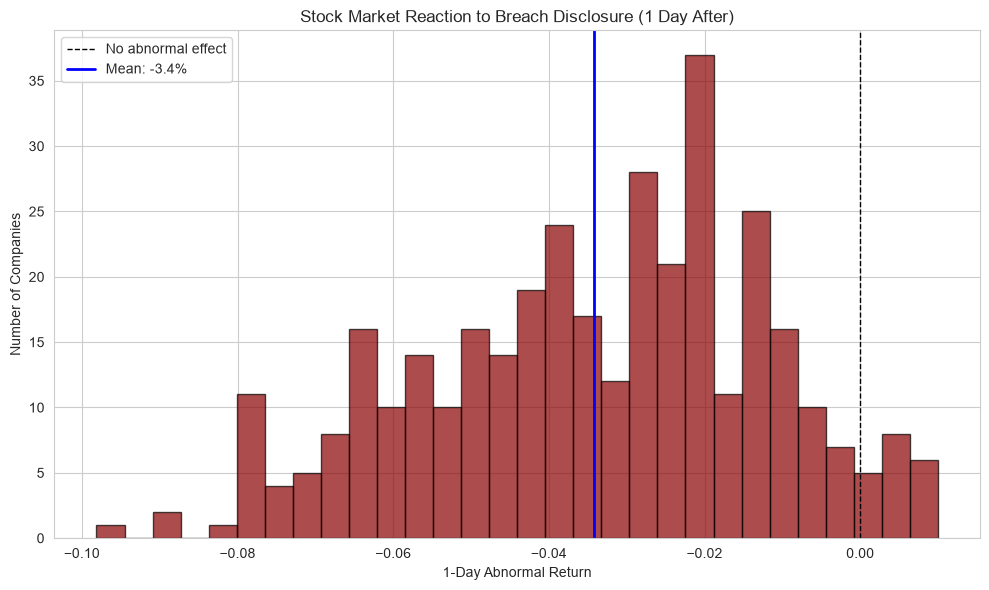

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(market_df['abnormal_return_1d'], bins=30, color='darkred', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No abnormal effect')
ax.axvline(market_df['abnormal_return_1d'].mean(), color='blue', linestyle='-', linewidth=2, label=f"Mean: {market_df['abnormal_return_1d'].mean():.1%}")
ax.set_xlabel('1-Day Abnormal Return')
ax.set_ylabel('Number of Companies')
ax.set_title('Stock Market Reaction to Breach Disclosure (1 Day After)')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/market_reaction_distribution.png', dpi=150)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Define target: is this incident above median total loss?
model_df = df.dropna(subset=['total_loss_usd']).copy()
median_loss = model_df['total_loss_usd'].median()
model_df['high_loss'] = (model_df['total_loss_usd'] > median_loss).astype(int)

print(f"Median loss: ${median_loss:,.0f}")
print(model_df['high_loss'].value_counts())

Median loss: $16,564,915
high_loss
1    389
0    389
Name: count, dtype: int64


In [27]:
features = ['company_revenue_usd', 'employee_count', 'is_public_company', 
            'industry_name', 'attack_vector_primary', 'data_compromised_records', 
            'downtime_hours']

model_data = model_df[features + ['high_loss']].dropna()
print(f"Rows available for modeling: {len(model_data)}")

X = model_data[features].copy()
y = model_data['high_loss']

# Encode categorical columns
le_industry = LabelEncoder()
le_vector = LabelEncoder()
X['industry_name'] = le_industry.fit_transform(X['industry_name'])
X['attack_vector_primary'] = le_vector.fit_transform(X['attack_vector_primary'])

X.head()

Rows available for modeling: 271


,company_revenue_usd,employee_count,is_public_company,industry_name,attack_vector_primary,data_compromised_records,downtime_hours
0,1.343769e+09,3940,True,6,2,26888.0,16.52
6,2.715680e+08,2121,True,9,0,58001.0,129.37
9,3.991403e+10,776266,True,15,2,30907.0,91.85
11,1.085375e+11,723769,True,15,0,143751.0,134.16
17,8.267924e+08,5756,False,13,2,13561.0,235.57


In [28]:
for f in features:
    missing = model_df[f].isnull().sum()
    print(f"{f}: {missing} missing ({missing/len(model_df)*100:.1f}%)")

company_revenue_usd: 0 missing (0.0%)
employee_count: 0 missing (0.0%)
is_public_company: 0 missing (0.0%)
industry_name: 0 missing (0.0%)
attack_vector_primary: 0 missing (0.0%)
data_compromised_records: 222 missing (28.5%)
downtime_hours: 390 missing (50.1%)


In [29]:
model_data = model_df[features + ['high_loss']].copy()

# Fill downtime and records with 0 - "no downtime/no data compromised" is a real, valid value here
model_data['downtime_hours'] = model_data['downtime_hours'].fillna(0)
model_data['data_compromised_records'] = model_data['data_compromised_records'].fillna(0)

# Drop only rows where the CORE features are missing (should be very few now)
model_data = model_data.dropna()

print(f"Rows available for modeling: {len(model_data)}")

X = model_data[features].copy()
y = model_data['high_loss']

le_industry = LabelEncoder()
le_vector = LabelEncoder()
X['industry_name'] = le_industry.fit_transform(X['industry_name'])
X['attack_vector_primary'] = le_vector.fit_transform(X['attack_vector_primary'])

X.head()

Rows available for modeling: 778


,company_revenue_usd,employee_count,is_public_company,industry_name,attack_vector_primary,data_compromised_records,downtime_hours
0,1.343769e+09,3940,True,6,6,26888.0,16.52
1,6.367059e+07,250,False,8,5,41426.0,0.00
2,2.480619e+10,71369,True,8,8,0.0,0.00
3,1.398259e+08,912,True,16,5,1107796.0,0.00
4,6.916977e+08,1662,True,8,2,621233.0,0.00


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.74      0.68        78
           1       0.68      0.55      0.61        78

    accuracy                           0.65       156
   macro avg       0.65      0.65      0.64       156
weighted avg       0.65      0.65      0.64       156



company_revenue_usd         0.250769
employee_count              0.247218
data_compromised_records    0.150609
downtime_hours              0.116666
industry_name               0.114339
attack_vector_primary       0.099190
is_public_company           0.021209
dtype: float64


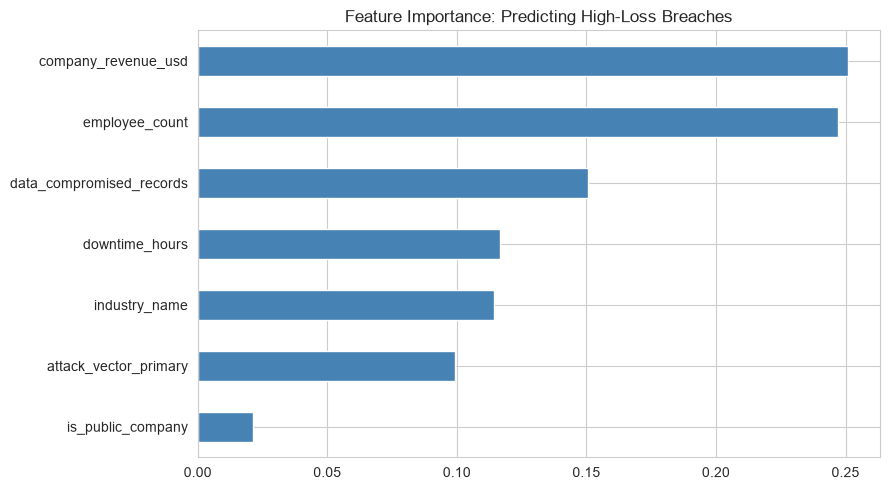

In [31]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance: Predicting High-Loss Breaches')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150)
plt.show()